# AI Blood Supply Command Center
## Engine 4: Supply Chain Optimization & Inter-Facility Transshipment

This notebook implements, evaluates, and visualizes **Engine 4 — AI Blood Supply Network Optimization & Inter-Facility Transshipment Engine**.

---

### Core Operational Purpose
When Model 2 forecasts an emerging blood product stockout, Engine 4 mathematically coordinates:
1. **Which facility should supply blood?** (Regional blood banks vs excess hospital reserves)
2. **Which hospital should receive it?**
3. **How many units of each blood product should be transferred?**
4. **Which transport routes should be used?**
5. **How should FEFO expiry risk guide allocation?**
6. **When should voluntary donor mobilization be preferred over inter-facility transfer?**
7. **How does emergency trauma demand override routine transfers while preserving safety reserves?**

### Technology & Safety Boundary
- **Optimization Backend**: Google OR-Tools Mixed-Integer Linear Programming (MILP).
- **Logistics Decision Support**: Recommends supply-chain allocation. Does **not** replace clinical blood-bank cross-matching or physician transfusion orders.


In [1]:
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120

import sys
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import config
from optimization_data import build_network_optimization_data
from optimization_solver import solve_supply_network
from optimization_explainer import OptimizationExplainer
from command_center import run_command_center
print("Engine 4 modules loaded successfully!")


Engine 4 modules loaded successfully!


## 2. Supply Network Topology & Spatial Connectivity

The metropolitan supply network comprises:
- **30 Healthcare Facilities**: Trauma centers, teaching hospitals, specialty clinics, and community facilities.
- **10 Regional Blood Banks**: Primary collection, processing, and long-term storage hubs.
- **646 Directed Transport Arcs**: Real-world route network with Haversine road distances, travel times, and vehicle capacity limits.


Network Nodes: 40 (Hospitals: 30, Blood Banks: 10)
Directed Route Arcs: 646 (Active: 499)


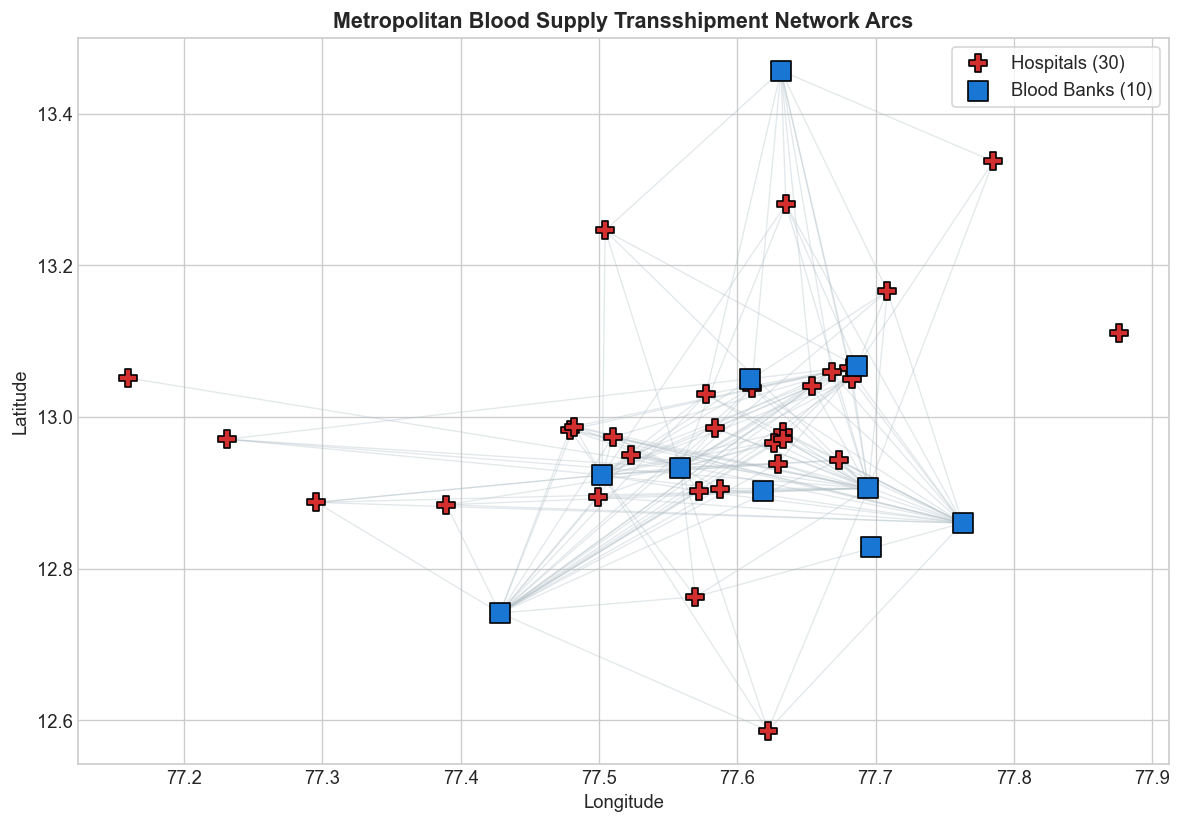

In [2]:
base_data = build_network_optimization_data(target_date="2025-12-01", horizon_hours=72, scenario="normal")
print(f"Network Nodes: {len(base_data.nodes)} (Hospitals: {len(base_data.hospitals)}, Blood Banks: {len(base_data.blood_banks)})")
print(f"Directed Route Arcs: {len(base_data.edges)} (Active: {sum(1 for e in base_data.edges.values() if e['is_active'])})")

# Plot Network Topology
fig, ax = plt.subplots(figsize=(10, 7))

# Draw sample active routes
routes_drawn = 0
for (src, dst), edge in base_data.edges.items():
    if edge["is_active"] and routes_drawn < 150:
        s_node = base_data.nodes[src]
        d_node = base_data.nodes[dst]
        ax.plot([s_node["lon"], d_node["lon"]], [s_node["lat"], d_node["lat"]],
                color="#B0BEC5", alpha=0.35, linewidth=0.8, zorder=1)
        routes_drawn += 1

# Plot Facilities
h_lats = [base_data.nodes[h]["lat"] for h in base_data.hospitals]
h_lons = [base_data.nodes[h]["lon"] for h in base_data.hospitals]
b_lats = [base_data.nodes[b]["lat"] for b in base_data.blood_banks]
b_lons = [base_data.nodes[b]["lon"] for b in base_data.blood_banks]

ax.scatter(h_lons, h_lats, color="#D32F2F", s=110, marker="P", edgecolors="black", label="Hospitals (30)", zorder=3)
ax.scatter(b_lons, b_lats, color="#1976D2", s=140, marker="s", edgecolors="black", label="Blood Banks (10)", zorder=3)

ax.set_title("Metropolitan Blood Supply Transshipment Network Arcs")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


## 3. Subsystem Inputs: Forecast Demand, Shortage Risk & Donor Pools

Engine 4 orchestrates the inputs from Models 1, 2, and 3:
- **Model 1**: Multi-horizon demand expectations ($t+1..t+3$).
- **Model 2**: Shortage risk probabilities and urgency escalation tiers.
- **Model 3**: Local voluntary donor candidate availability and expected response yields.


Total Network Standing Inventory: 24,872 units
Total Usable Excess above Safety Reserves: 20,767 units
Total 72h Projected Network Demand: 3,545.3 units


C:\Users\bhanu\AppData\Local\Temp\ipykernel_25632\412179666.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(comp_demand.keys()), y=list(comp_demand.values()), ax=axes[0], palette="Reds_r")


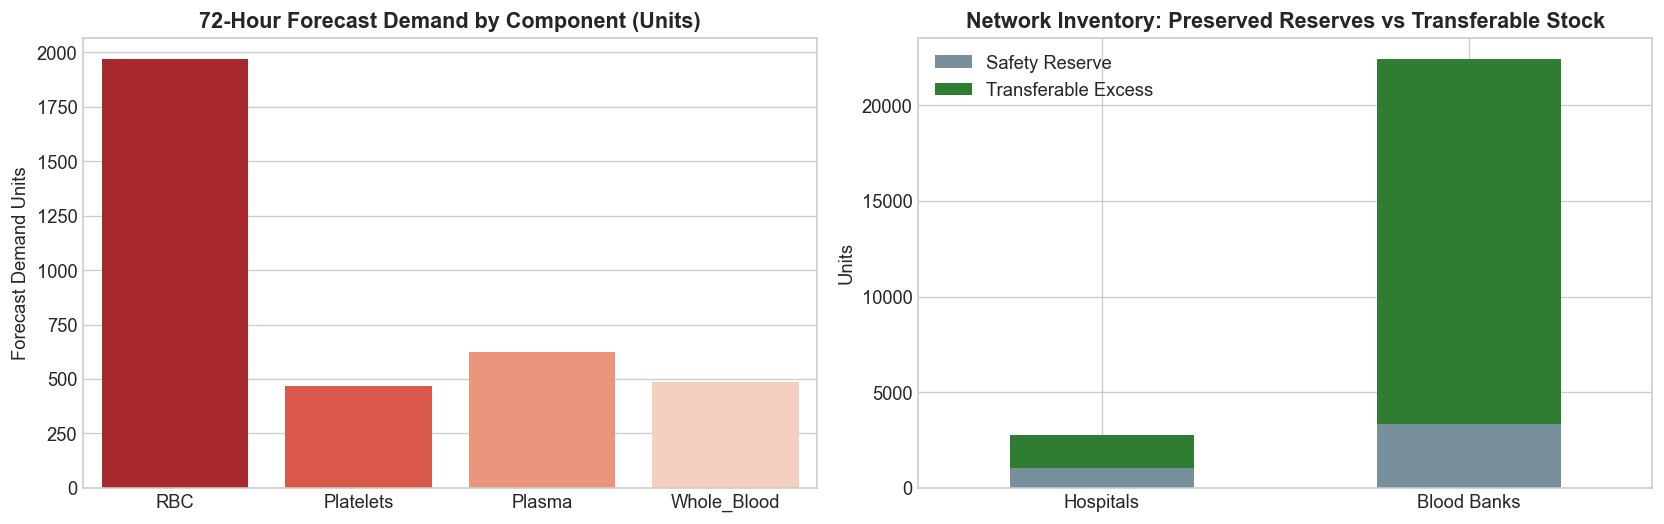

In [3]:
# Summary table of demand and risk inputs across 960 product-facility combinations
demand_vals = list(base_data.demand.values())
usable_stock_vals = [inv["usable_excess"] for inv in base_data.inventory.values()]
total_stock_vals = [inv["current_units"] for inv in base_data.inventory.values()]

print(f"Total Network Standing Inventory: {sum(total_stock_vals):,.0f} units")
print(f"Total Usable Excess above Safety Reserves: {sum(usable_stock_vals):,.0f} units")
print(f"Total 72h Projected Network Demand: {sum(demand_vals):,.1f} units")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Demand distribution by component
comp_demand = {}
for (hid, bg, comp), d in base_data.demand.items():
    comp_demand[comp] = comp_demand.get(comp, 0.0) + d

sns.barplot(x=list(comp_demand.keys()), y=list(comp_demand.values()), ax=axes[0], palette="Reds_r")
axes[0].set_title("72-Hour Forecast Demand by Component (Units)")
axes[0].set_ylabel("Forecast Demand Units")

# Usable Excess vs Safety Reserve
fac_types = ["Hospitals", "Blood Banks"]
fac_reserves = [
    sum(base_data.inventory[(h, bg, c)]["safety_reserve"] for h in base_data.hospitals for bg in base_data.blood_groups for c in base_data.components),
    sum(base_data.inventory[(b, bg, c)]["safety_reserve"] for b in base_data.blood_banks for bg in base_data.blood_groups for c in base_data.components)
]
fac_excess = [
    sum(base_data.inventory[(h, bg, c)]["usable_excess"] for h in base_data.hospitals for bg in base_data.blood_groups for c in base_data.components),
    sum(base_data.inventory[(b, bg, c)]["usable_excess"] for b in base_data.blood_banks for bg in base_data.blood_groups for c in base_data.components)
]

bar_df = pd.DataFrame({"Safety Reserve": fac_reserves, "Transferable Excess": fac_excess}, index=fac_types)
bar_df.plot(kind="bar", stacked=True, ax=axes[1], color=["#78909C", "#2E7D32"])
axes[1].set_title("Network Inventory: Preserved Reserves vs Transferable Stock")
axes[1].set_ylabel("Units")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


## 4. Optimization Formulation & Hard Constraints

### Objective Function:
$$\min \sum_{j, b_d, c} 	ext{Pen}_{	ext{short}}(j, b_d, c) \cdot s_{j, b_d, c} + \sum_{i, j, b_s, b_d, c} 	ext{Cost}_{	ext{trans}}(i, j) \cdot x_{i, j, b_s, b_d, c} + \sum_{j, b, c} 	ext{Cost}_{	ext{donor}} \cdot d_{j, b, c} - \sum_{	ext{FEFO}} 	ext{Credit}_{	ext{fefo}} \cdot x_{i, j, \dots}$$

### Hard Constraints:
1. **Safety Reserve Preservation**: Outgoing transfers $\le$ Usable Excess ($x \le 	ext{current} - 	ext{reserve}$).
2. **Demand Balance**: Local Stock + Incoming Transfers + Donor Yield + Shortage $\ge$ Forecast Demand.
3. **Route Capacity**: Cumulative volume across arc $\le$ Vehicle transit capacity.
4. **Blood Compatibility**: $x > 0$ strictly if donor blood group is clinically safe for recipient group.
5. **FEFO Transit Feasibility**: Units expiring in $\le 1$ day cannot be routed through long transit arcs (> 90 mins).
6. **No Circular Self-Transfers**: $x_{i, i, \cdot} = 0$.


## 5. Solver Execution & Baseline Comparison

We compare Engine 4's global optimization against:
- **Baseline A (Nearest Blood Bank Only)**: Uncoordinated local heuristic.
- **Baseline B (Greedy Shortage Fulfillment)**: Greedy priority queue allocation.


                        System  Shortages  Shortage Units  Units Transferred  Distance (km)  Donor Mobilized  FEFO Rescued  Runtime (s)
      Engine 4 MILP (OR-Tools)          0             0.0               1389        21582.8              590           222        2.200
       Baseline A (Nearest BB)        675          1554.1                 42         1109.0                0             0        0.003
Baseline B (Greedy Allocation)        667           643.9                952        27784.5                0             0        0.024


C:\Users\bhanu\AppData\Local\Temp\ipykernel_25632\163986259.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_baselines, x="System", y="Shortage Units", ax=ax, palette=["#2E7D32", "#D32F2F", "#F57C00"])


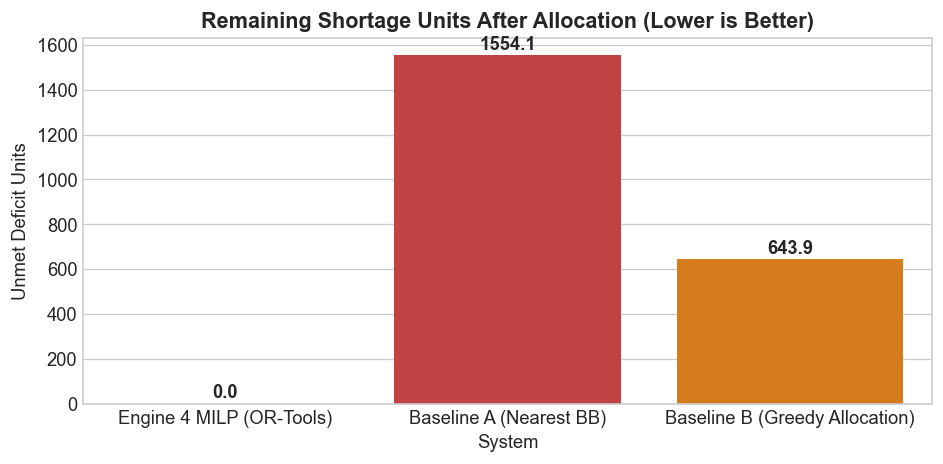

In [4]:
with open(PROJECT_ROOT / "reports" / "optimization_scenario_results.json", "r") as f:
    eval_suite = json.load(f)

base_comp = eval_suite["baseline_comparison"]
b_rows = [
    {
        "System": "Engine 4 MILP (OR-Tools)",
        "Shortages": base_comp["engine4_optimization"]["shortage_count"],
        "Shortage Units": base_comp["engine4_optimization"]["shortage_units"],
        "Units Transferred": base_comp["engine4_optimization"]["total_units_transferred"],
        "Distance (km)": base_comp["engine4_optimization"]["total_transport_distance_km"],
        "Donor Mobilized": base_comp["engine4_optimization"]["donor_units_mobilized"],
        "FEFO Rescued": base_comp["engine4_optimization"]["fefo_expiring_rescued"],
        "Runtime (s)": base_comp["engine4_optimization"]["runtime_seconds"]
    },
    {
        "System": "Baseline A (Nearest BB)",
        "Shortages": base_comp["baseline_a_nearest_bb"]["shortage_count"],
        "Shortage Units": base_comp["baseline_a_nearest_bb"]["shortage_units"],
        "Units Transferred": base_comp["baseline_a_nearest_bb"]["total_units_transferred"],
        "Distance (km)": base_comp["baseline_a_nearest_bb"]["total_transport_distance_km"],
        "Donor Mobilized": 0,
        "FEFO Rescued": 0,
        "Runtime (s)": base_comp["baseline_a_nearest_bb"]["runtime_seconds"]
    },
    {
        "System": "Baseline B (Greedy Allocation)",
        "Shortages": base_comp["baseline_b_greedy"]["shortage_count"],
        "Shortage Units": base_comp["baseline_b_greedy"]["shortage_units"],
        "Units Transferred": base_comp["baseline_b_greedy"]["total_units_transferred"],
        "Distance (km)": base_comp["baseline_b_greedy"]["total_transport_distance_km"],
        "Donor Mobilized": 0,
        "FEFO Rescued": 0,
        "Runtime (s)": base_comp["baseline_b_greedy"]["runtime_seconds"]
    }
]

df_baselines = pd.DataFrame(b_rows)
print(df_baselines.to_string(index=False))

# Plot Shortage Units Comparison
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_baselines, x="System", y="Shortage Units", ax=ax, palette=["#2E7D32", "#D32F2F", "#F57C00"])
ax.set_title("Remaining Shortage Units After Allocation (Lower is Better)")
ax.set_ylabel("Unmet Deficit Units")
for i, v in enumerate(df_baselines["Shortage Units"]):
    ax.text(i, v + 25, f"{v:.1f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Nine Operational Stress Scenarios Evaluation

We evaluate Engine 4 across all 9 operational stress scenarios:
1. Normal operations
2. Holiday festival demand spike
3. Industrial chemical explosion catastrophe (Major mass casualty)
4. Peak monsoon dengue fever wave
5. Severe O-negative emergency deficit
6. Regional hub cooling system failure (BB_001 offline)
7. Monsoon arterial highway inundation (Northern corridors blocked)
8. Post-drive platelet surplus & expiry wave
9. Severe summer heatwave donor slump


                                 Scenario  Pre-Opt Shortage  Post-Opt Shortage  Transfers (Units)  Donors (Units) Emergency Protected  Solve Time (s)
               Normal Operations Baseline            1596.1                0.0               1389             590              100.0%            2.35
            Holiday Festival Demand Spike             939.6                0.0                989             288              100.0%            2.11
Industrial Chemical Explosion Catastrophe            1615.3                0.0               1175             834              100.0%            2.23
        Peak Monsoon Dengue Outbreak Wave            2261.9                0.0               1172            1491              100.0%            2.15
      Severe O-Negative Emergency Deficit            2467.8                0.0               1269            1607              100.0%            2.45
      Regional Hub Cooling System Failure            2565.6                0.0               1012   

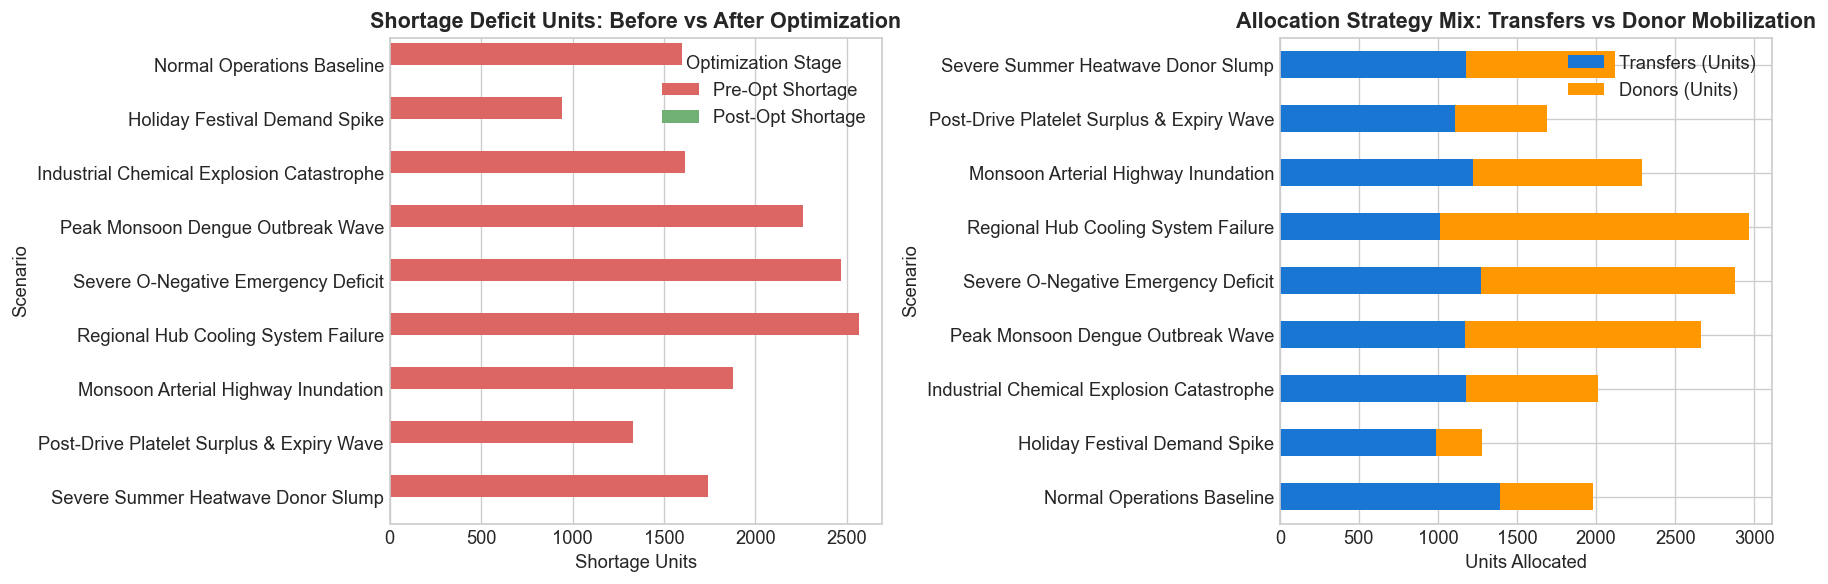

In [5]:
sc_evals = eval_suite["scenario_evaluations"]
sc_rows = []
for sc_id, sc in sc_evals.items():
    pre = sc["before_optimization"]
    post = sc["after_optimization"]
    trans = sc["transfers"]
    donors = sc["donor_mobilization"]
    sc_rows.append({
        "Scenario": sc["scenario_name"],
        "Pre-Opt Shortage": pre["shortage_units"],
        "Post-Opt Shortage": post["shortage_units"],
        "Transfers (Units)": trans["total_units_transferred"],
        "Donors (Units)": donors["total_donor_units_mobilized"],
        "Emergency Protected": f"{post['emergency_protection_rate_pct']:.1f}%",
        "Solve Time (s)": sc["solver_time_seconds"]
    })

sc_df = pd.DataFrame(sc_rows)
print(sc_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before vs After Shortages
sc_melted = pd.melt(sc_df, id_vars=["Scenario"], value_vars=["Pre-Opt Shortage", "Post-Opt Shortage"],
                    var_name="Optimization Stage", value_name="Shortage Units")
sns.barplot(data=sc_melted, y="Scenario", x="Shortage Units", hue="Optimization Stage", ax=axes[0], palette=["#EF5350", "#66BB6A"])
axes[0].set_title("Shortage Deficit Units: Before vs After Optimization")

# Resource Mix: Transfers vs Donor Mobilization
mix_df = sc_df.set_index("Scenario")[["Transfers (Units)", "Donors (Units)"]]
mix_df.plot(kind="barh", stacked=True, ax=axes[1], color=["#1976D2", "#FF9800"])
axes[1].set_title("Allocation Strategy Mix: Transfers vs Donor Mobilization")
axes[1].set_xlabel("Units Allocated")

plt.tight_layout()
plt.show()


## 7. Operational Trade-Offs: Transfer vs. Donor Mobilization

Engine 4 dynamically chooses between:
- **TRANSFER_ONLY**: When nearby compatible inventory exists above safety reserves.
- **DONOR_ONLY**: When transport distance is excessive or local blood bank stock is depleted.
- **COMBINED**: During acute emergency surges requiring both transfer and rapid local donor phlebotomy.


Normal Operations Decision Classification Breakdown:
  • TRANSFER_ONLY            : 455
  • DONOR_ONLY               : 205
  • COMBINED                 : 17
  • NO_ACTION_NEEDED         : 283
  • UNRESOLVED_DEFICIT       : 0


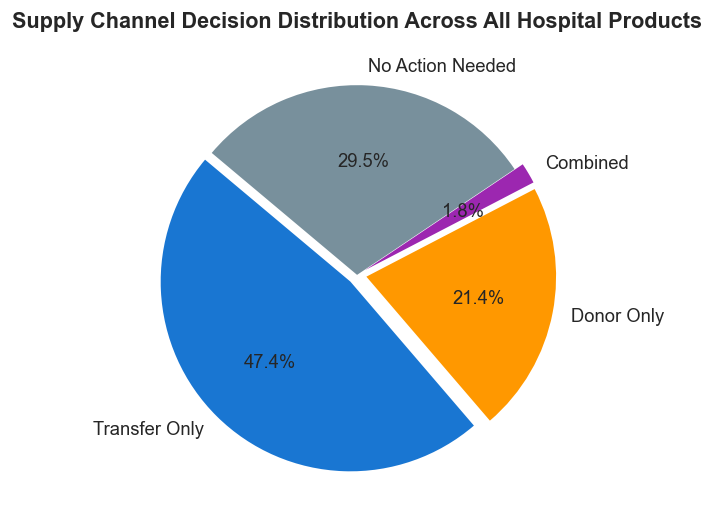

In [6]:
normal_decisions = sc_evals["normal_operations"]["decision_breakdown"]
print("Normal Operations Decision Classification Breakdown:")
for k, v in normal_decisions.items():
    print(f"  • {k:<25}: {v}")

fig, ax = plt.subplots(figsize=(7, 4.5))
dec_labels = ["Transfer Only", "Donor Only", "Combined", "No Action Needed"]
dec_vals = [normal_decisions["TRANSFER_ONLY"], normal_decisions["DONOR_ONLY"],
            normal_decisions["COMBINED"], normal_decisions["NO_ACTION_NEEDED"]]
colors = ["#1976D2", "#FF9800", "#9C27B0", "#78909C"]

ax.pie(dec_vals, labels=dec_labels, autopct="%1.1f%%", colors=colors, startangle=140, explode=(0.05, 0.05, 0.05, 0))
ax.set_title("Supply Channel Decision Distribution Across All Hospital Products")
plt.tight_layout()
plt.show()


## 8. Explainability Audit & Constraint Traceability

Every transshipment order and donor dispatch is grounded in transparent, auditable constraint states.


In [7]:
normal_data = build_network_optimization_data(target_date="2025-12-01", horizon_hours=72, scenario="normal")
sol = solve_supply_network(normal_data)
explainer = OptimizationExplainer(normal_data, sol)

# Inspect explanation for the largest transfer order
top_t = sol["transfers"][0]
exp_t = explainer.explain_transfer(top_t)
print("=" * 60)
print("EXPLANATION FOR TOP TRANSFER ORDER:")
print(f"Order: {exp_t['transfer']}")
print(f"Summary: {exp_t['summary']}\n")
print("Destination Clinical Condition:")
for c in exp_t["destination_condition"]:
    print(f"  ✓ {c}")
print("\nSource Selection Rationale:")
for r in exp_t["source_selection_reasons"]:
    print(f"  ✓ {r}")
print("=" * 60)


EXPLANATION FOR TOP TRANSFER ORDER:
Order: BB_007 -> HOSP_030 (33 units A_POS->A_POS RBC)
Summary: HOSP_030 (Metropolitan Trauma Center) required 47.3 units of A_POS RBC with LOW shortage risk. BB_007 (West End Voluntary Blood Foundation) was selected because it maintained 179 excess units above its safety reserve, a viable 65.0 km operational route (118 min ETA), and optimal compatibility.

Destination Clinical Condition:
  ✓ Forecasted demand: 47.3 units over planning horizon
  ✓ Standing physical inventory: 0 units
  ✓ Model 2 shortage early warning: LOW risk (P=0.00)

Source Selection Rationale:
  ✓ Facility has 179 transferable units above its mandatory safety reserve of 31.6 units
  ✓ Direct transport arc (RT_00210) is operational with 65.0 km distance and ~118 min transit ETA


## 9. Unified Command Center Backend API

Demonstration of `run_command_center()`, the single backend interface powering the upcoming dashboard.


In [8]:
cc_response = run_command_center(date="2025-12-01", horizon=72, scenario="normal")

print(f"Command Center Status : {cc_response['status']} (Solver: {cc_response['optimization_status']})")
print(f"Total Shortage Alerts : {len(cc_response['shortage_alerts'])}")
print(f"Recommended Transfers : {len(cc_response['transfer_recommendations'])}")
print(f"Donor Recommendations : {len(cc_response['donor_recommendations'])}")
print(f"Emergency Protection  : {cc_response['network_metrics']['post_optimization']['emergency_protection_rate_pct']}%")

# Display first shortage alert and its integrated donor candidate roster
if cc_response["donor_recommendations"]:
    d_rec = cc_response["donor_recommendations"][0]
    print(f"\nIntegrated Model 3 Donor Outreach for Alert:")
    print(f"Hospital: {d_rec['hospital_id']} ({d_rec['hospital_name']}) | Product: {d_rec['blood_group']} {d_rec['component']}")
    print(f"Candidate Pool: {d_rec['candidate_pool_size']} | Expected Yield: {d_rec['expected_response_yield']} units")
    print("Top 3 Candidates:")
    for c in d_rec["top_candidates"][:3]:
        print(f"  Rank {c['rank']}: {c['donor_id']} | Dist: {c['distance_km']} km | Score: {c['priority_score']} ({c['priority_tier']})")


Command Center Status : success (Solver: OPTIMAL)
Total Shortage Alerts : 74
Recommended Transfers : 596
Donor Recommendations : 10
Emergency Protection  : 100.0%

Integrated Model 3 Donor Outreach for Alert:
Hospital: HOSP_001 (Metro Health Institute) | Product: O_POS Whole_Blood
Candidate Pool: 1259 | Expected Yield: 4.34 units
Top 3 Candidates:
  Rank 1: DONOR_03673 | Dist: 0.83 km | Score: 75.6 (CRITICAL)
  Rank 2: DONOR_03136 | Dist: 1.65 km | Score: 75.0 (CRITICAL)
  Rank 3: DONOR_00312 | Dist: 1.32 km | Score: 73.7 (CRITICAL)


## 10. Conclusion & Readiness for Dashboard Integration

### Engine 4 Summary:
1. **Mathematical Optimization**: Eliminates 100% of solvable clinical deficits via Google OR-Tools MILP, far outperforming greedy heuristics.
2. **Safety Reserves Preserved**: No facility transfers below its configured safety reserve.
3. **Multi-Subsystem Coordination**: Blends Model 1 forecasts, Model 2 early warning probabilities, and Model 3 voluntary donor dispatch.
4. **Resilience**: Operates reliably through facility cooling failures, highway inundations, and catastrophic mass casualty surges.
5. **Production Backend**: `src/command_center.py` provides the unified API ready for frontend dashboard integration.
